In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedba

In [3]:
# 20 classes, as well as none.
classes = {
    0:'None',
    1:'Aeroplane',
    2:'Bicycle',
    3:'Bird',
    4:'Boat',
    5:'Bottle',
    6:'Bus',
    7:'Car',
    8:'Cat',
    9:'Chair',
    10:'Cow',
    11:'Diningtable',
    12:'Dog',
    13:'Horse',
    14:'Motorbike',
    15:'Person',
    16:'Pottedplant',
    17:'Sheep',
    18:'Sofa',
    19:'Train',
    20:'Tvmonitor',
}
# num_classes = len(classes)
num_classes = 2

In [4]:
class OneHotMap(nn.Module):
    def __init__(self, num_classes, trunc_mode='clip'):
        super().__init__()
        self.num_classes = num_classes
        self.trunc_mode = trunc_mode

    def forward(self, x):
        if self.trunc_mode == 'clip':
            # Any class higher than num_classes is set to the highest class number.
            x = torch.clamp_max(x, self.num_classes - 1)
        elif self.trunc_mode == 'background':
            # Any class higher than num_classes is set to background
            x[x > (self.num_classes -1)] = 0
        else:
            raise Exception("Invalid truncation mode")
        
        x = F.one_hot(x.long(), self.num_classes)
        return x.squeeze(0).permute(2, 0, 1)
        
def onehot_label(lbl, num_classes):
    c, h, w = lbl.shape # c is always 1
    out = F.one_hot(lbl, num_classes)

    return out.squeeze(0).permute(2, 0, 1)

In [5]:
# 500x500 is the max width and height in voc. Images may not be square,
# but are always equal to or smaller than 500x500.
# We use 512 since it's a nice power of 2.
voc_dim = (512, 512)
train_tfs_v2 = tv2.Compose([
    tv2.RandomHorizontalFlip(0.5),
    tv2.RandomResizedCrop(voc_dim),
    tv2.RandomPhotometricDistort(p=0.5),
    tv2.ToImageTensor(),
    tv2.ConvertImageDtype(torch.float32),
])

val_tfs_v2 = tv2.Compose([
    tv2.Resize(voc_dim),
    tv2.ToImageTensor(),
    tv2.ConvertImageDtype(torch.float32),
])

voc_train = tds.VOCSegmentation(
    root=dataset_root,
    download=True,
    year='2012',
    image_set='train',
    transforms=train_tfs_v2
)
voc_train = tds.wrap_dataset_for_transforms_v2(voc_train)


voc_val = tds.VOCSegmentation(
    root=dataset_root,
    download=True,
    year='2012',
    image_set='val',
    transforms=val_tfs_v2
)
voc_val = tds.wrap_dataset_for_transforms_v2(voc_val)


Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets
Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets


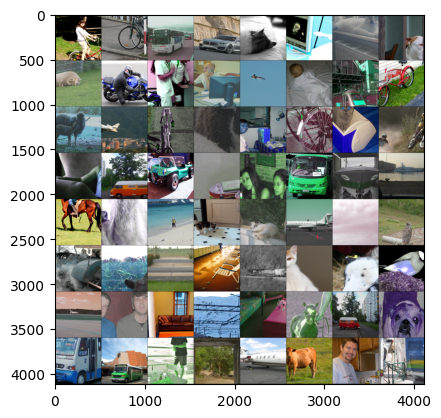

In [6]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(voc_train, k=num)])
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())

In [7]:
batchsize = 8

train_loader = tud.DataLoader(
    voc_train,
    batch_size=batchsize,
    num_workers=8,
    shuffle=True)
val_loader = tud.DataLoader(
    voc_val,
    batch_size=batchsize,
    num_workers=8,
    shuffle=True)

In [8]:
class DownConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.conv_1 = nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1)
        self.bn_1 = nn.BatchNorm2d(cout)
        
        self.conv_2 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(cout)

    def forward(self, x):
        x = self.conv_1(x)
        x = F.relu(x)
        x = self.bn_1(x)
        
        x = self.conv_2(x)
        x = F.relu(x)
        x = self.bn_2(x)
        return x

class UpConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.upconv_1 = nn.ConvTranspose2d(cin, cout, kernel_size=2, stride=2)
        self.bn_1 = nn.BatchNorm2d(cout)

        # Cat with through connection happens here, which doubles the number of channels.
        
        self.conv_2 = nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(cout)
        
        self.conv_3 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1)
        self.bn_3 = nn.BatchNorm2d(cout)

    def forward(self, x, xcat):
        # Cat on channel dim
        x = self.upconv_1(x)
        x = self.bn_1(x)

        tmp = torch.cat((x, xcat), dim=1)
        
        x = self.conv_2(tmp)
        x = F.relu(x)
        x = self.bn_2(x)

        x = self.conv_3(x)
        x = F.relu(x)
        x = self.bn_3(x)
        
        return x
    
class UnetSeg(nn.Module):
    def __init__(self, cin, cout=num_classes, filts=32):
        super().__init__()
        self.l1 = DownConv(cin, filts)
        self.l2 = DownConv(filts, filts*2)
        self.l3 = DownConv(filts*2, filts*4)
        self.l4 = DownConv(filts*4, filts*8)

        self.thru = nn.Sequential(
            nn.Conv2d(filts*8, filts*16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(filts*16),
            nn.Conv2d(filts*16, filts*16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(filts*16)
        )
    
        self.u1 = UpConv(filts*16, filts*8)
        self.u2 = UpConv(filts*8, filts*4)
        self.u3 = UpConv(filts*4, filts*2)
        self.u4 = UpConv(filts*2, filts)
        # Increase the amount of filters at the end of the network
        self.out7 = nn.Conv2d(filts, num_classes, kernel_size=1, stride=1)

    def forward(self, x):
        # Down
        x0 = self.l1(x)
        x1 = self.l2(F.max_pool2d(x0, kernel_size=2))
        x2 = self.l3(F.max_pool2d(x1, kernel_size=2))
        x3 = self.l4(F.max_pool2d(x2, kernel_size=2))

        # xb -> x bottleneck
        xb = self.thru(F.max_pool2d(x3, kernel_size=2))

        # Up
        xu3 = self.u1(xb, x3)
        xu4 = self.u2(xu3, x2)
        xu5 = self.u3(xu4, x1)
        xu6 = self.u4(xu5, x0)

        # Output
        xout = self.out7(xu6)
        return xout

In [13]:
from torchinfo import summary
testmodel = UnetSeg(3, num_classes, filts=8)
lossfn = nn.CrossEntropyLoss()
print(summary(testmodel, (1, 3, 512, 512)))

Layer (type:depth-idx)                   Output Shape              Param #
UnetSeg                                  [1, 2, 512, 512]          --
├─DownConv: 1-1                          [1, 8, 512, 512]          --
│    └─Conv2d: 2-1                       [1, 8, 512, 512]          224
│    └─BatchNorm2d: 2-2                  [1, 8, 512, 512]          16
│    └─Conv2d: 2-3                       [1, 8, 512, 512]          584
│    └─BatchNorm2d: 2-4                  [1, 8, 512, 512]          16
├─DownConv: 1-2                          [1, 16, 256, 256]         --
│    └─Conv2d: 2-5                       [1, 16, 256, 256]         1,168
│    └─BatchNorm2d: 2-6                  [1, 16, 256, 256]         32
│    └─Conv2d: 2-7                       [1, 16, 256, 256]         2,320
│    └─BatchNorm2d: 2-8                  [1, 16, 256, 256]         32
├─DownConv: 1-3                          [1, 32, 128, 128]         --
│    └─Conv2d: 2-9                       [1, 32, 128, 128]         4,640
│   

In [10]:
class ToOneHot(nn.Module):
    def __init__(self, num_classes, trunc_mode='clip'):
        super().__init__()
        self.num_classes = num_classes
        self.trunc_mode = trunc_mode

    def forward(self, x):
        if self.trunc_mode == 'clip':
            # Any class higher than num_classes is set to the highest class number.
            x = torch.clamp_max(x, self.num_classes - 1)
        elif self.trunc_mode == 'background':
            # Any class higher than num_classes is set to background
            x[x > (self.num_classes -1)] = 0
        else:
            raise Exception("Invalid truncation mode")
        
        x = F.one_hot(x.long(), self.num_classes)
        return x.squeeze(1).permute(0, 3, 1, 2)
        

In [11]:
%%time

model = UnetSeg(3, num_classes, filts=8).to(device).train()
onehot_transform = ToOneHot(num_classes, trunc_mode='clip')

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0)
epochs = 100
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

lossfn = nn.CrossEntropyLoss()
# lossfn = nn.MSELoss()
train_loss_plot = []
loss_plot = []
try:
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for i, (images, targets) in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            images = images.float().to(device)
            targets = onehot_transform(targets).float().to(device)
    
            outs = model(images)
            loss = lossfn(outs, targets)
            loss.backward()
            train_losses.append(loss.cpu().item())
            optimizer.step()

        train_loss = torch.Tensor(train_losses).mean().item()
        print("Train Loss {}: {} ".format(epoch, train_loss))
        train_loss_plot.append(train_loss)

        if epoch % 5 == 0:
            losses = []
            model.eval()
            correct = 0
            total = len(voc_val)
            print("Running val...")
            with torch.no_grad():
                for i, (images, targets) in enumerate(tqdm(val_loader)):
                    images = images.float().to(device)
                    targets = onehot_transform(targets).float().to(device)
                    outs = model(images)
        
                    loss = lossfn(outs, targets)
                    losses.append(loss.cpu().item())
                        
            eval_loss = torch.Tensor(losses).mean().item()
            print("Eval Loss {}: {} ".format(epoch, eval_loss))
            print("Current LR is {}".format(scheduler.get_last_lr()))
        loss_plot.append(eval_loss)
        scheduler.step()
        
except KeyboardInterrupt:
    plt.plot(loss_plot)
    plt.plot(train_loss_plot)
    
plt.plot(loss_plot)
plt.plot(train_loss_plot)

100%|█████████████████████████████████████████████| 183/183 [00:09<00:00, 18.54it/s]


Train Loss 0: 0.661729097366333 
Running val...


100%|█████████████████████████████████████████████| 182/182 [00:04<00:00, 45.13it/s]


Eval Loss 0: 0.6625152230262756 
Current LR is [0.01]


100%|█████████████████████████████████████████████| 183/183 [00:09<00:00, 18.66it/s]


...

Eval Loss 25: 0.5694803595542908 
Current LR is [0.0001]


100%|█████████████████████████████████████████████| 183/183 [00:09<00:00, 18.73it/s]


Train Loss 26: 0.5308493375778198 


  0%|                                                       | 0/183 [00:00<?, ?it/s]Exception ignored in: <function _releaseLock at 0x7fbb2dba0ee0>
Traceback (most recent call last):
  File "/home/kyle/micromamba/envs/ml/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 
  0%|                                                       | 0/183 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 1484380, 1484449, 1484476, 1484500, 1484524) exited unexpectedly

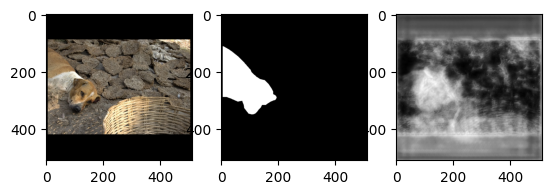

In [12]:
ix = 153
data, label = voc_val[ix]
label = onehot_transform(label)

input = data.float().cuda().unsqueeze(0)

thresh = 0.25
with torch.no_grad():
    model.eval()
    pred = model(input)
    pred = F.softmax(pred, dim=1)

fig, (ax1, ax2, ax3) = plt.subplots(1,3)
ax1.imshow(data.permute(1,2,0))
ax2.imshow(label.squeeze()[1], cmap='gray')
ax3.imshow(pred[0, 1, ...].cpu(), cmap='gray')